In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
    explained_variance_score,
    max_error
)

In [2]:
data = 'Dataset/Housing.csv'

df= pd.read_csv(data)

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
le = LabelEncoder()
for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

In [9]:
X = df.drop("price", axis=1)
y = df["price"]

In [10]:
x1, x2, y1, y2 = train_test_split(X, y,test_size=0.2,random_state=42)

In [11]:
model = LinearRegression()
model.fit(x1, y1)

LinearRegression()

In [12]:
y_pred = model.predict(x2)
y_pred

array([5203691.70963178, 7257004.02115476, 3062828.59668172,
       4559591.65374424, 3332932.30559782, 3563080.67918997,
       5645466.31219972, 6413979.66873635, 2755831.54819   ,
       2668938.66075229, 9570600.29915353, 2827431.50860062,
       3195686.2583409 , 3352263.99438471, 3713879.49996131,
       5301088.24435749, 2987920.2666968 , 4810799.8212371 ,
       4383031.70489929, 3525092.18938647, 5796259.50068013,
       5840000.70299301, 2760214.608641  , 4762590.14920607,
       5204755.73895206, 7515542.71619025, 3254681.68956382,
       5236164.45964444, 8178523.16820284, 3434166.15675649,
       6443921.58767581, 3346004.77919184, 6742324.74004133,
       4154936.84088665, 3589152.47491253, 5788125.92515323,
       4768370.18154076, 4391684.04193171, 3217657.04549935,
       4638196.61928878, 4522160.27786714, 3541284.06127245,
       7238136.11941171, 4021515.68926614, 3701978.76822757,
       4298879.55563098, 6705004.0206061 , 3993466.52296896,
       3798185.05328059,

In [14]:
mae = mean_absolute_error(y2, y_pred)
mse = mean_squared_error(y2, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y2, y_pred)
mape = mean_absolute_percentage_error(y2, y_pred)
evs = explained_variance_score(y2, y_pred)
maxerr = max_error(y2, y_pred)

In [15]:
n = x2.shape[0]      # Number of observations
p = x2.shape[1]      # Number of predictors

adj_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

In [16]:
print("\n========== Regression Evaluation ==========")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Adjusted R² Score: {adj_r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")
print(f"Explained Variance Score: {evs:.4f}")
print(f"Maximum Error: {maxerr:.2f}")


========== Regression Evaluation ==========
Mean Absolute Error (MAE): 979679.69
Mean Squared Error (MSE): 1771751116594.03
Root Mean Squared Error (RMSE): 1331071.42
R² Score: 0.6495
Adjusted R² Score: 0.6057
Mean Absolute Percentage Error (MAPE): 0.2131
Explained Variance Score: 0.6534
Maximum Error: 5295927.59


In [17]:
print("\nIntercept:")
print(model.intercept_)


# In[21]:


print("\nCoefficients:")
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coef)


Intercept:
293083.0691506723

Coefficients:
             Feature   Coefficient
0               area  2.358488e+02
1           bedrooms  7.857449e+04
2          bathrooms  1.097117e+06
3            stories  4.062232e+05
4           mainroad  3.668242e+05
5          guestroom  2.331468e+05
6           basement  3.931598e+05
7    hotwaterheating  6.878813e+05
8    airconditioning  7.855506e+05
9            parking  2.257565e+05
10          prefarea  6.299017e+05
11  furnishingstatus -2.103971e+05


In [18]:
new_house = [[5000,3,2,2,1,1,0,1,0,1,0,1]]

prediction = model.predict(new_house)

print("\nPredicted House Price:", prediction[0])


Predicted House Price: 6017942.931156619


C:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


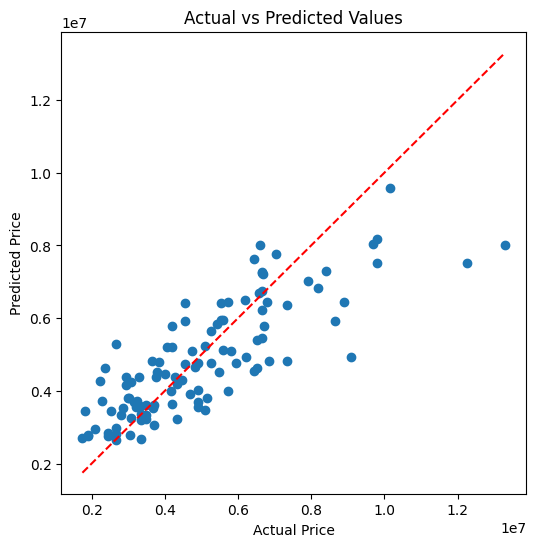

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,6))
plt.scatter(y2, y_pred)
plt.plot([y2.min(), y2.max()],
         [y2.min(), y2.max()],
         'r--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Values")
plt.show()
